In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

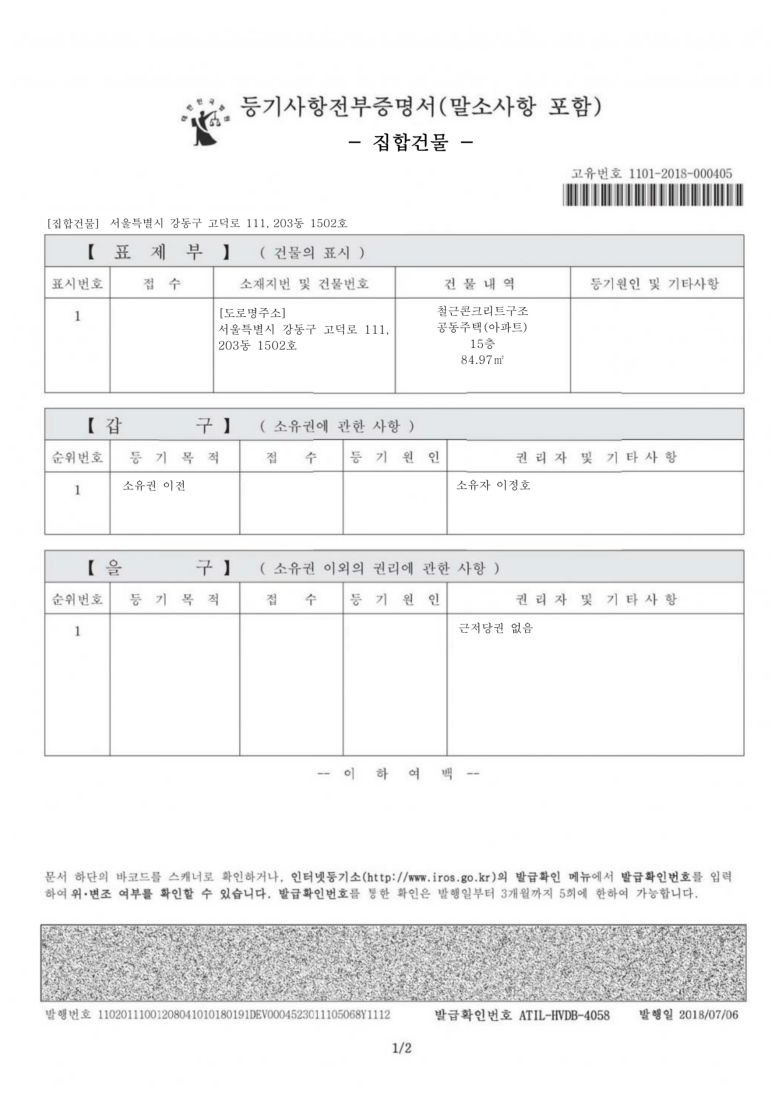

In [3]:
IMAGE_PATH = "../data/등기사항증명서 - 김민수_page_001.png"

img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 14))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

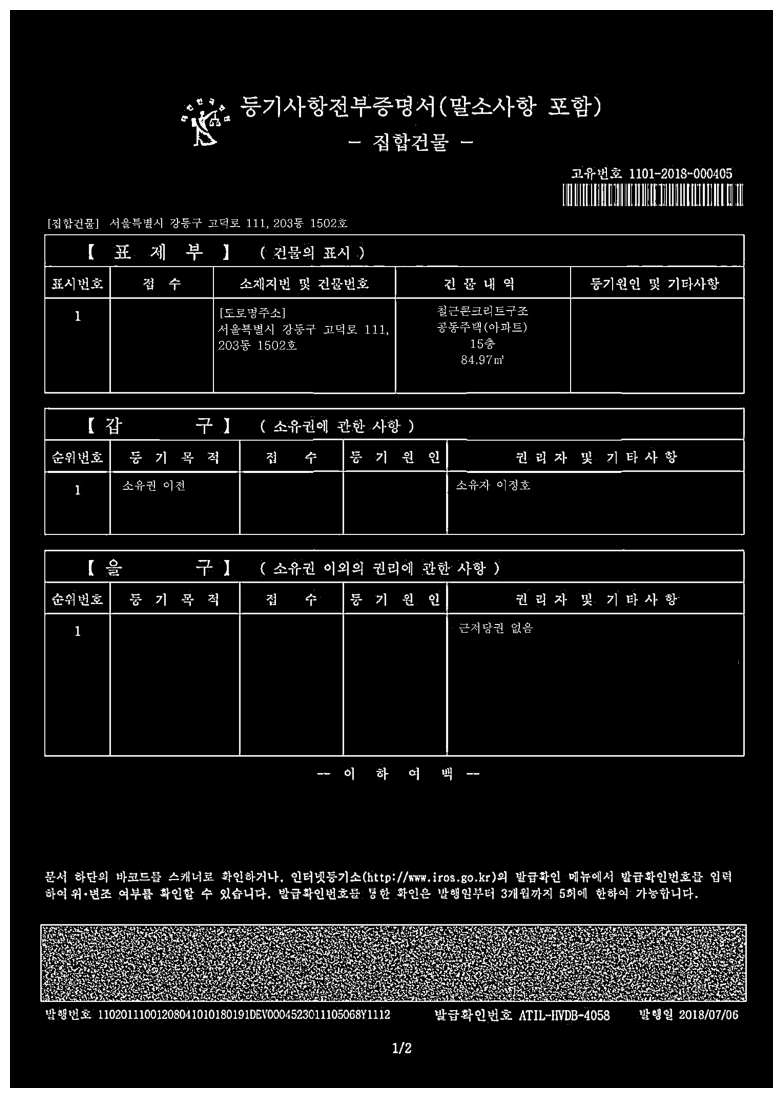

In [4]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 문서 스캔은 보통 adaptive threshold가 안정적
bin_img = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15, 8
)

plt.figure(figsize=(10, 14))
plt.imshow(bin_img, cmap="gray")
plt.axis("off")
plt.show()

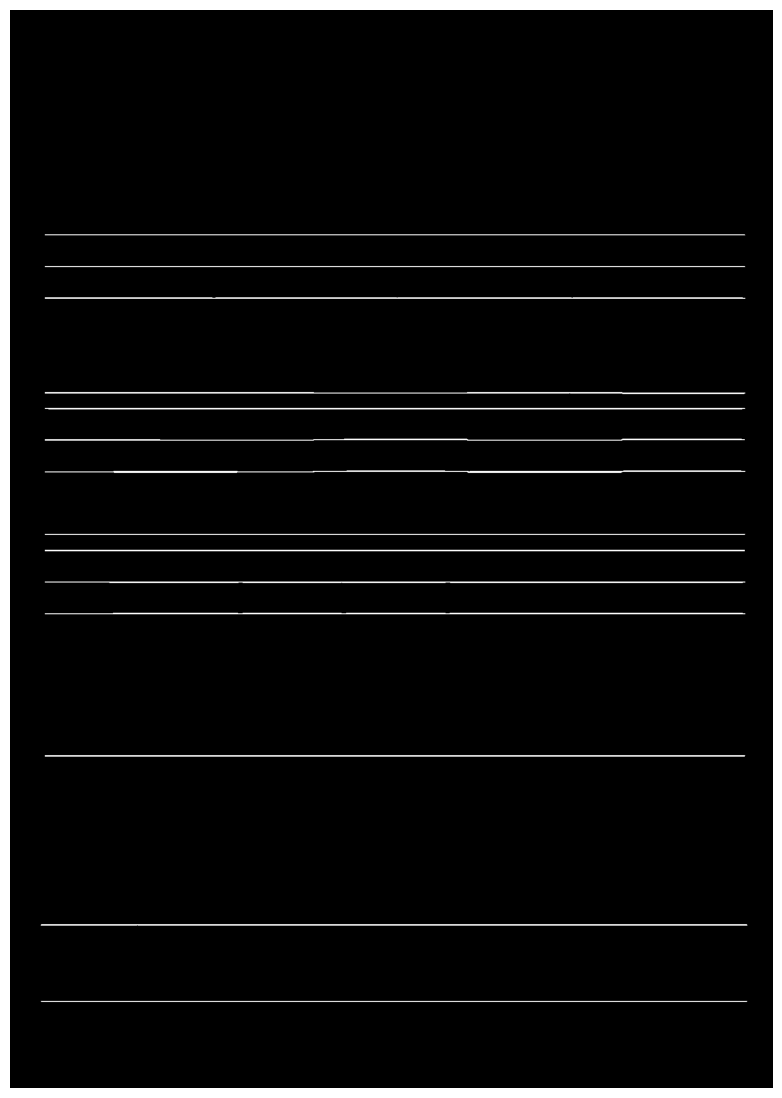

In [5]:
h, w = bin_img.shape

horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (w // 8, 1))
horizontal_lines = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, horizontal_kernel)

plt.figure(figsize=(10, 14))
plt.imshow(horizontal_lines, cmap="gray")
plt.axis("off")
plt.show()

In [6]:
# 선 + 글자 덩어리를 좀 합치기
merge_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 15))
merged = cv2.dilate(bin_img, merge_kernel, iterations=1)

contours, _ = cv2.findContours(merged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

boxes = []
for cnt in contours:
    x, y, bw, bh = cv2.boundingRect(cnt)
    
    area = bw * bh
    # 너무 작은 잡음 제거
    if area < 5000:
        continue
    
    # 너무 얇은 줄만 있는 것도 제거 가능
    if bw < w * 0.2 or bh < 20:
        continue
    
    boxes.append([x, y, x + bw, y + bh])

boxes = sorted(boxes, key=lambda b: b[1])
boxes[:10]

[[438, 156, 1164, 217],
 [1067, 296, 1443, 390],
 [55, 399, 1446, 763],
 [48, 769, 1446, 1033],
 [55, 1046, 1446, 1465],
 [56, 1674, 1419, 1745],
 [47, 1778, 1450, 1988]]

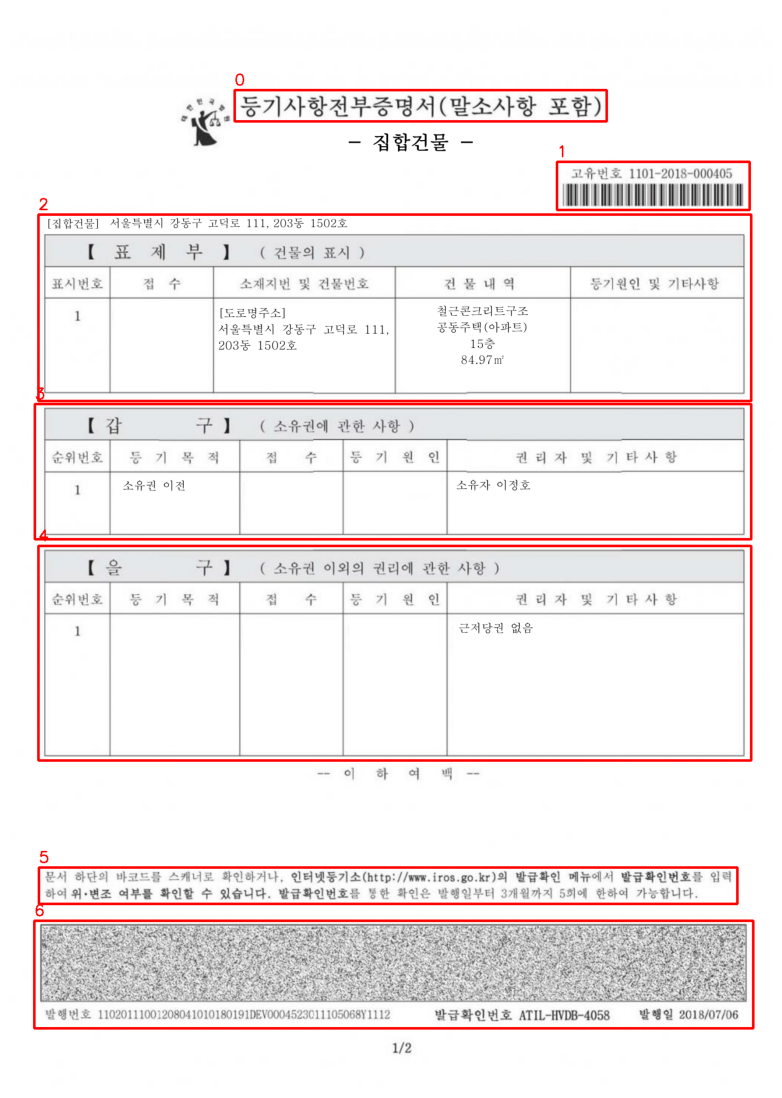

In [7]:
vis = img_rgb.copy()

for i, (x1, y1, x2, y2) in enumerate(boxes):
    cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 3)
    cv2.putText(vis, str(i), (x1, max(30, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 0), 2)

plt.figure(figsize=(10, 14))
plt.imshow(vis)
plt.axis("off")
plt.show()

In [11]:
def merge_boxes_by_y(boxes, y_gap_threshold=30):
    if not boxes:
        return []

    boxes = sorted(boxes, key=lambda b: b[1])
    merged = [boxes[0]]

    for box in boxes[1:]:
        x1, y1, x2, y2 = box
        lx1, ly1, lx2, ly2 = merged[-1]

        # 다음 박스가 바로 아래에 있으면 합침
        if y1 - ly2 <= y_gap_threshold:
            nx1 = min(lx1, x1)
            ny1 = min(ly1, y1)
            nx2 = max(lx2, x2)
            ny2 = max(ly2, y2)
            merged[-1] = [nx1, ny1, nx2, ny2]
        else:
            merged.append(box)

    return merged

In [12]:
merged_boxes = merge_boxes_by_y(boxes, y_gap_threshold=40)
merged_boxes

[[438, 156, 1164, 217], [48, 296, 1446, 1465], [47, 1674, 1450, 1988]]

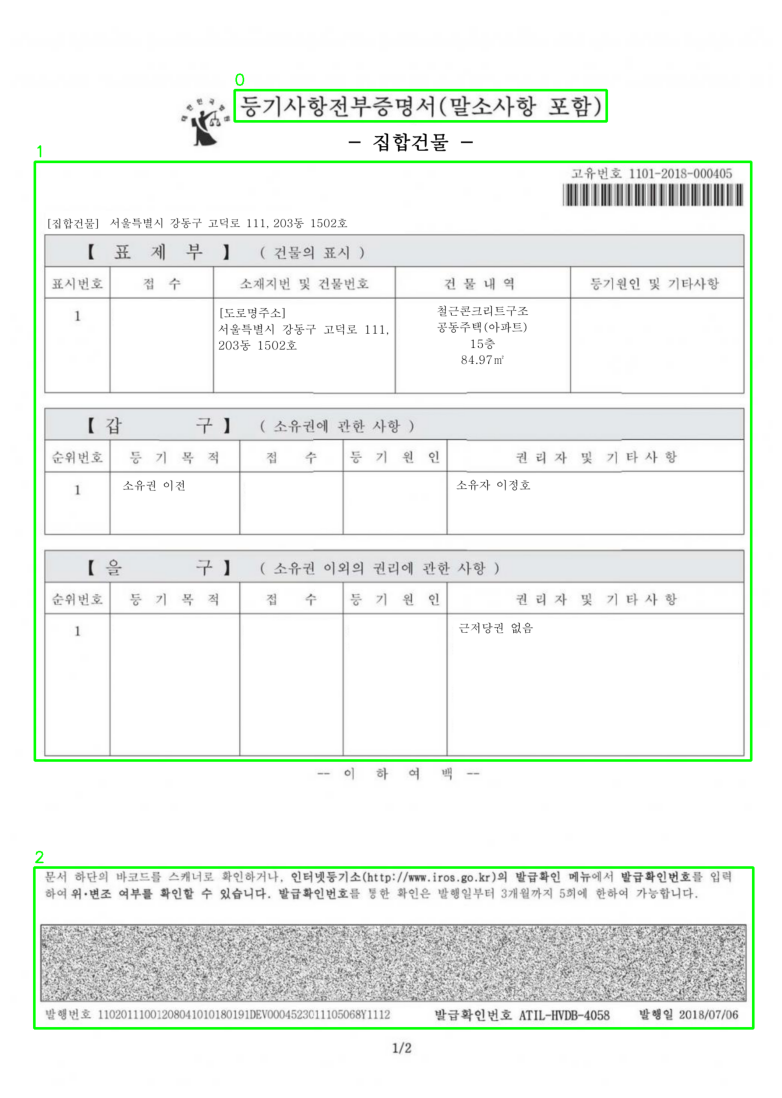

In [13]:
vis2 = img_rgb.copy()

for i, (x1, y1, x2, y2) in enumerate(merged_boxes):
    cv2.rectangle(vis2, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(vis2, str(i), (x1, max(30, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)

plt.figure(figsize=(10, 14))
plt.imshow(vis2)
plt.axis("off")
plt.show()

In [9]:
def show_crops(image_rgb, boxes, cols=2):
    n = len(boxes)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for idx, (x1, y1, x2, y2) in enumerate(boxes):
        r, c = divmod(idx, cols)
        crop = image_rgb[y1:y2, x1:x2]
        axes[r, c].imshow(crop)
        axes[r, c].set_title(f"{idx}: {(x1, y1, x2, y2)}")
        axes[r, c].axis("off")

    for idx in range(n, rows * cols):
        r, c = divmod(idx, cols)
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

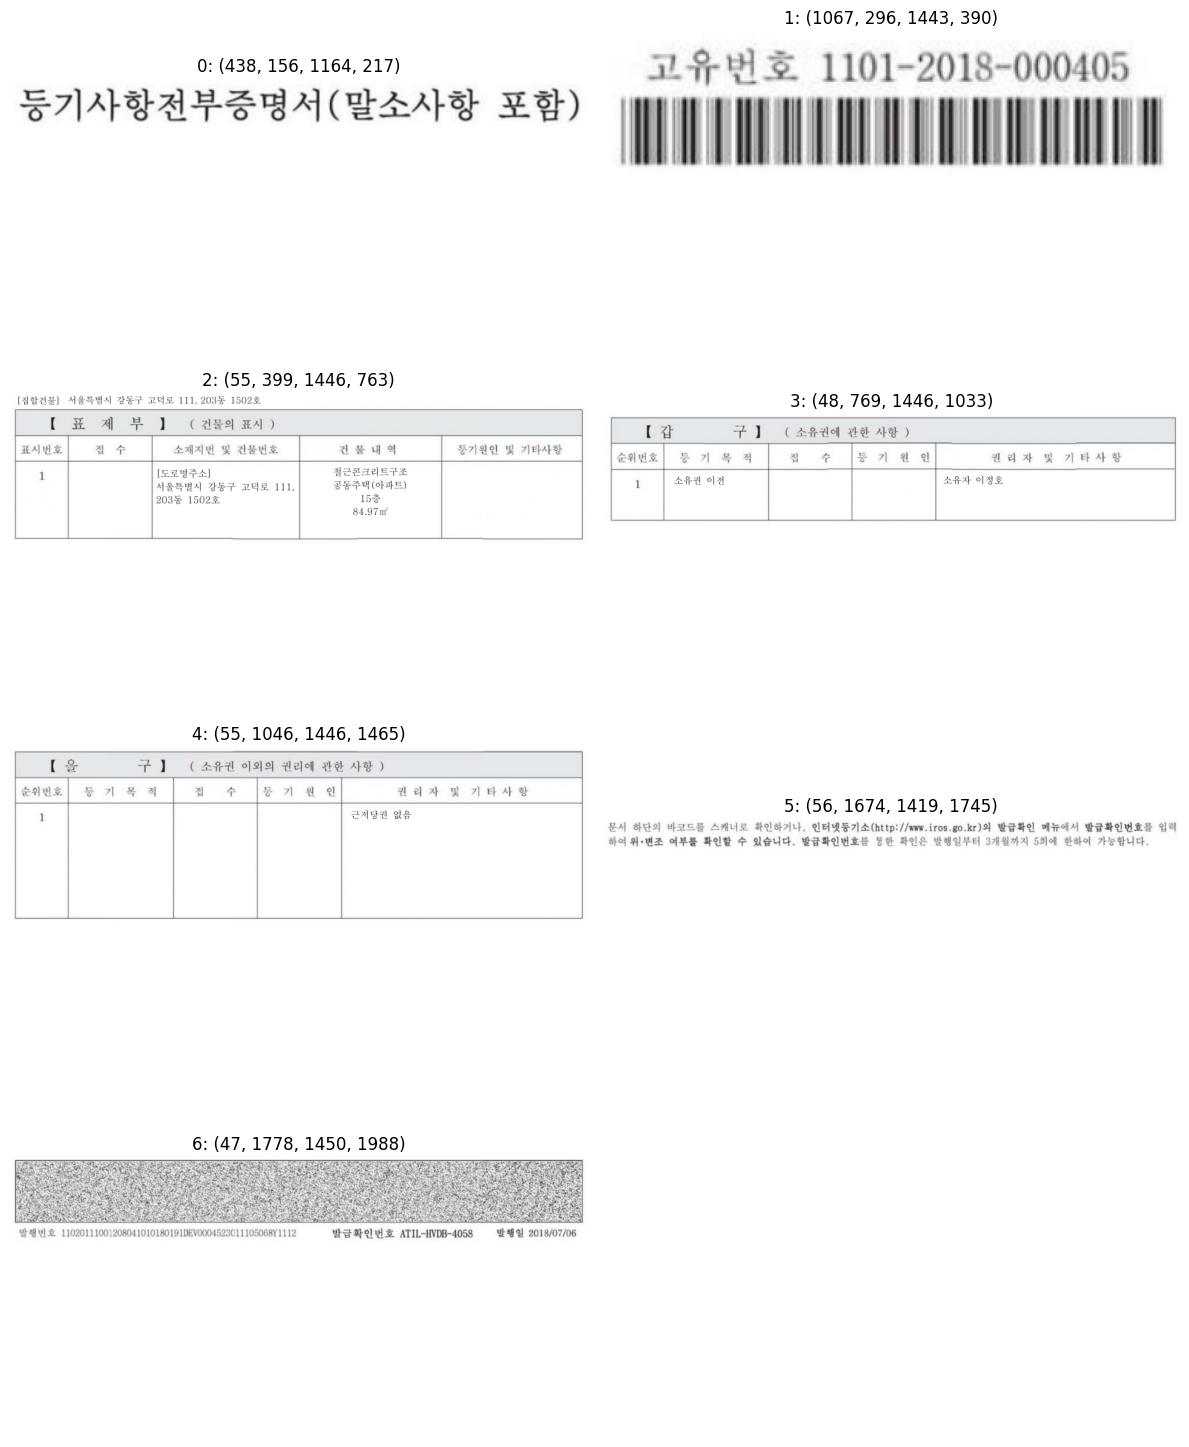

In [10]:
show_crops(img_rgb, boxes, cols=2)

### 건축물대장

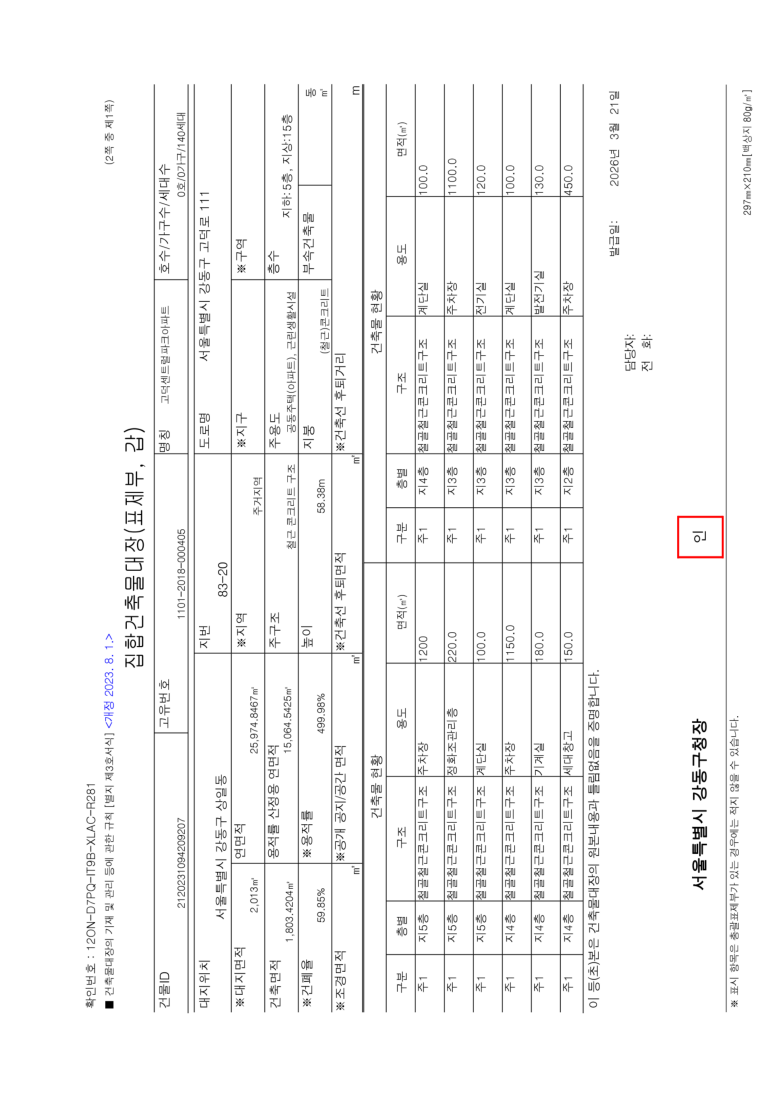

In [16]:
IMAGE_PATH = "../data/집합건축물대장 갑- 김민수_page_001.png"

img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 14))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

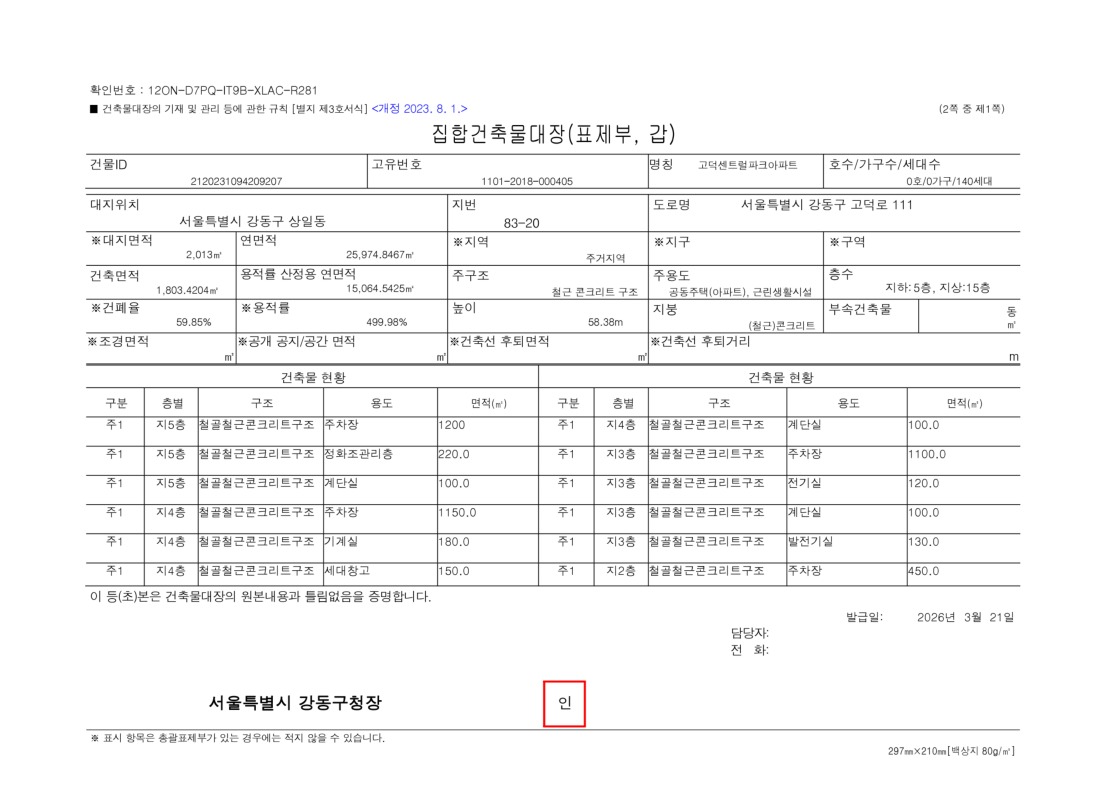

In [17]:
rotated = cv2.rotate(img_bgr, cv2.ROTATE_90_CLOCKWISE)
rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.imshow(rotated_rgb)
plt.axis("off")
plt.show()

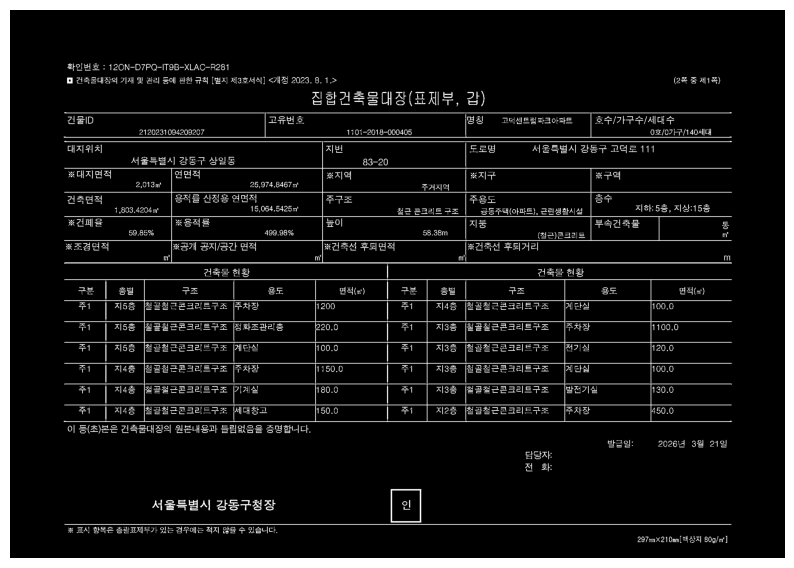

In [19]:
gray = cv2.cvtColor(rotated_rgb, cv2.COLOR_BGR2GRAY)

# 문서 스캔은 보통 adaptive threshold가 안정적
bin_img = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15, 8
)

plt.figure(figsize=(10, 14))
plt.imshow(bin_img, cmap="gray")
plt.axis("off")
plt.show()

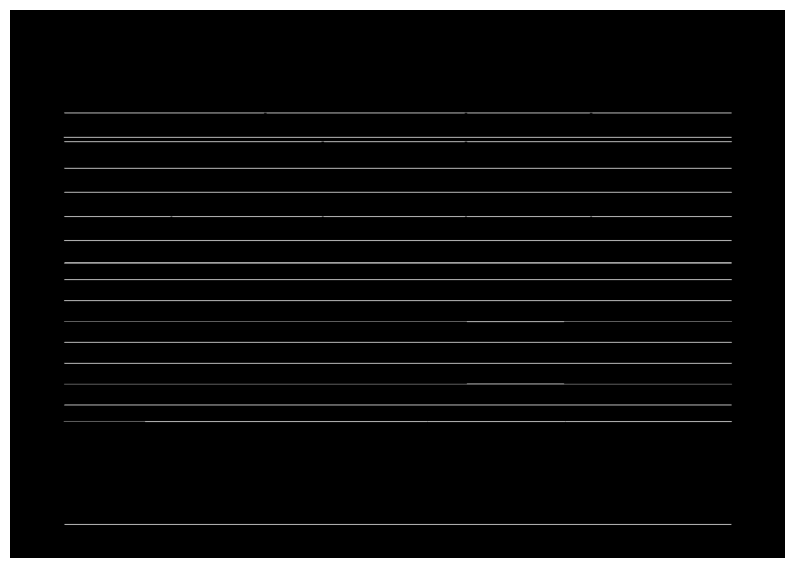

In [20]:
h, w = bin_img.shape

horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (w // 8, 1))
horizontal_lines = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, horizontal_kernel)

plt.figure(figsize=(10, 14))
plt.imshow(horizontal_lines, cmap="gray")
plt.axis("off")
plt.show()

In [28]:
# 선 + 글자 덩어리를 좀 합치기
merge_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 15))
merged = cv2.dilate(bin_img, merge_kernel, iterations=1)

contours, _ = cv2.findContours(merged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

boxes = []
for cnt in contours:
    x, y, bw, bh = cv2.boundingRect(cnt)
    
    area = bw * bh
    # 너무 작은 잡음 제거
    if area < 5000:
        continue
    
    # 너무 얇은 줄만 있는 것도 제거 가능
    if bw < w * 0.2 or bh < 20:
        continue
    
    boxes.append([x, y, x + bw, y + bh])

boxes = sorted(boxes, key=lambda b: b[1])
boxes[:10]

[[144, 140, 605, 175],
 [143, 176, 899, 211],
 [808, 215, 1301, 271],
 [134, 273, 1973, 1158],
 [136, 1295, 1972, 1430]]

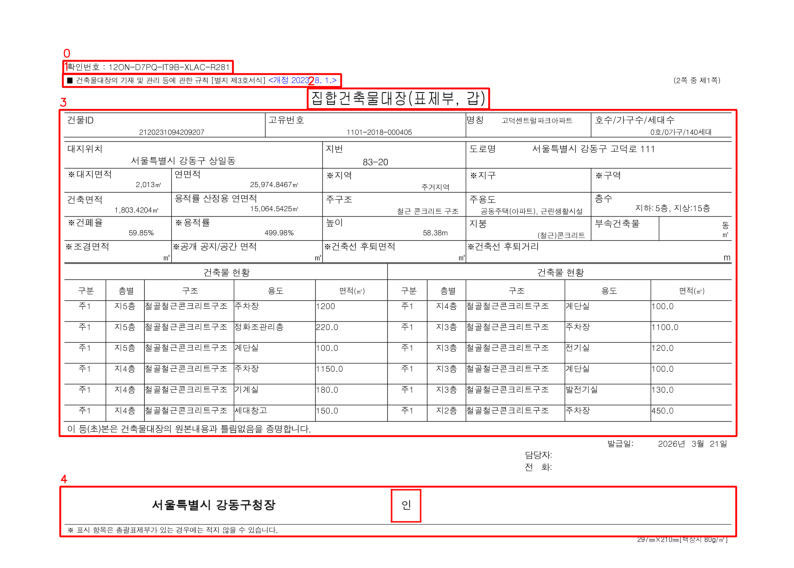

In [29]:
vis = rotated_rgb.copy()

for i, (x1, y1, x2, y2) in enumerate(boxes):
    cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 3)
    cv2.putText(vis, str(i), (x1, max(30, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 0), 2)

plt.figure(figsize=(10, 14))
plt.imshow(vis)
plt.axis("off")
plt.show()